In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 61.2 MB/s eta 0:00:00


In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.1 MB/s eta 0:00:00


In [ ]:
import torch
import rdkit
import torch_geometric

print("PyTorch:", torch.__version__)
print("RDKit:", rdkit.__version__)
print("PyTorch Geometric:", torch_geometric.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
RDKit: 2026.03.5
PyTorch Geometric: 2.8.0.post1
CUDA available: True
GPU: Tesla T4


In [ ]:
import pandas as pd

url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (2050, 4)

Columns:
['num', 'name', 'p_np', 'smiles']

First 5 rows:


,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...


In [ ]:
print("Target value counts:")
print(df["p_np"].value_counts())

print("\nTarget proportions:")
print(df["p_np"].value_counts(normalize=True))

print("\nMissing values:")
print(df.isnull().sum())

Target value counts:
p_np
1    1567
0     483
Name: count, dtype: int64

Target proportions:
p_np
1    0.76439
0    0.23561
Name: proportion, dtype: float64

Missing values:
num       0
name      0
p_np      0
smiles    0
dtype: int64


In [ ]:
print("Example molecule names:")
print(df["name"].head(10).to_string(index=False))

print("\nExample SMILES:")
print(df["smiles"].head(10).to_string(index=False))

Example molecule names:
          Propanolol
Terbutylchlorambucil
               40730
                  24
         cloxacillin
        cefoperazone
    rolitetracycline
         ondansetron
           diltiazem
           Amiloride

Example SMILES:
                  [Cl].CC(C)NCC(O)COc1cccc2ccccc12
          C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO3)=O
                  C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)[...
CCN1CCN(C(=O)N[C@@H](C(=O)N[C@H]2[C@H]3SCC(=C(N...
CN(C)[C@H]1[C@@H]2C[C@H]3C(=C(O)c4c(O)cccc4[C@@...
               Cn1c2CCC(Cn3ccnc3C)C(=O)c2c4ccccc14
COc1ccc(cc1)[C@@H]2Sc3ccccc3N(CCN(C)C)C(=O)[C@@...
                      NC(N)=NC(=O)c1nc(Cl)c(N)nc1N


In [ ]:
from rdkit import Chem

smiles = df.loc[0, "smiles"]

molecule = Chem.MolFromSmiles(smiles)

print("SMILES:")
print(smiles)

print("\nNumber of atoms:", molecule.GetNumAtoms())
print("Number of bonds:", molecule.GetNumBonds())

print("\nAtoms:")
for atom in molecule.GetAtoms():
    print(
        "Index:", atom.GetIdx(),
        "| Element:", atom.GetSymbol(),
        "| Atomic Number:", atom.GetAtomicNum()
    )

print("\nBonds:")
for bond in molecule.GetBonds():
    print(
        "Bond:", bond.GetBeginAtomIdx(),
        "↔",
        bond.GetEndAtomIdx(),
        "| Type:", bond.GetBondType()
    )

SMILES:
[Cl].CC(C)NCC(O)COc1cccc2ccccc12

Number of atoms: 20
Number of bonds: 20

Atoms:
Index: 0 | Element: Cl | Atomic Number: 17
Index: 1 | Element: C | Atomic Number: 6
Index: 2 | Element: C | Atomic Number: 6
Index: 3 | Element: C | Atomic Number: 6
Index: 4 | Element: N | Atomic Number: 7
Index: 5 | Element: C | Atomic Number: 6
Index: 6 | Element: C | Atomic Number: 6
Index: 7 | Element: O | Atomic Number: 8
Index: 8 | Element: C | Atomic Number: 6
Index: 9 | Element: O | Atomic Number: 8
Index: 10 | Element: C | Atomic Number: 6
Index: 11 | Element: C | Atomic Number: 6
Index: 12 | Element: C | Atomic Number: 6
Index: 13 | Element: C | Atomic Number: 6
Index: 14 | Element: C | Atomic Number: 6
Index: 15 | Element: C | Atomic Number: 6
Index: 16 | Element: C | Atomic Number: 6
Index: 17 | Element: C | Atomic Number: 6
Index: 18 | Element: C | Atomic Number: 6
Index: 19 | Element: C | Atomic Number: 6

Bonds:
Bond: 1 ↔ 2 | Type: SINGLE
Bond: 2 ↔ 3 | Type: SINGLE
Bond: 2 ↔ 4 | Ty

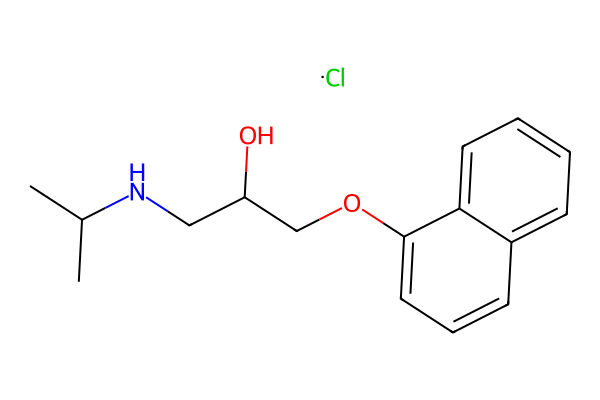

In [ ]:
from rdkit.Chem import Draw

img = Draw.MolToImage(molecule, size=(600, 400))
display(img)

In [ ]:
from rdkit import Chem

def atom_features(atom):
    """
    Convert an RDKit atom into a numerical feature vector.
    """

    atomic_number = atom.GetAtomicNum()
    degree = atom.GetDegree()
    formal_charge = atom.GetFormalCharge()
    num_hydrogens = atom.GetTotalNumHs()
    hybridization = int(atom.GetHybridization())
    aromatic = int(atom.GetIsAromatic())

    return [
        atomic_number,
        degree,
        formal_charge,
        num_hydrogens,
        hybridization,
        aromatic
    ]

In [ ]:
for atom in molecule.GetAtoms():
    print(
        f"Atom {atom.GetIdx():2d} "
        f"{atom.GetSymbol():2s} → "
        f"{atom_features(atom)}"
    )

Atom  0 Cl → [17, 0, 0, 0, 4, 0]
Atom  1 C  → [6, 1, 0, 3, 4, 0]
Atom  2 C  → [6, 3, 0, 1, 4, 0]
Atom  3 C  → [6, 1, 0, 3, 4, 0]
Atom  4 N  → [7, 2, 0, 1, 4, 0]
Atom  5 C  → [6, 2, 0, 2, 4, 0]
Atom  6 C  → [6, 3, 0, 1, 4, 0]
Atom  7 O  → [8, 1, 0, 1, 4, 0]
Atom  8 C  → [6, 2, 0, 2, 4, 0]
Atom  9 O  → [8, 2, 0, 0, 3, 0]
Atom 10 C  → [6, 3, 0, 0, 3, 1]
Atom 11 C  → [6, 2, 0, 1, 3, 1]
Atom 12 C  → [6, 2, 0, 1, 3, 1]
Atom 13 C  → [6, 2, 0, 1, 3, 1]
Atom 14 C  → [6, 3, 0, 0, 3, 1]
Atom 15 C  → [6, 2, 0, 1, 3, 1]
Atom 16 C  → [6, 2, 0, 1, 3, 1]
Atom 17 C  → [6, 2, 0, 1, 3, 1]
Atom 18 C  → [6, 2, 0, 1, 3, 1]
Atom 19 C  → [6, 3, 0, 0, 3, 1]


In [ ]:
import torch
from torch_geometric.data import Data


def molecule_to_graph(molecule, label=None):
    """
    Convert an RDKit molecule into a PyTorch Geometric graph.

    Nodes  = atoms
    Edges  = chemical bonds
    x      = atom feature matrix
    y      = optional target label
    """

    # -------------------------
    # 1. Create node features
    # -------------------------
    node_features = []

    for atom in molecule.GetAtoms():
        node_features.append(atom_features(atom))

    x = torch.tensor(node_features, dtype=torch.float)


    # -------------------------
    # 2. Create edge index
    # -------------------------
    edges = []

    for bond in molecule.GetBonds():

        start = bond.GetBeginAtomIdx()
        end = bond.GetEndAtomIdx()

        # Add both directions
        edges.append([start, end])
        edges.append([end, start])

    edge_index = torch.tensor(
        edges,
        dtype=torch.long
    ).t().contiguous()


    # -------------------------
    # 3. Create graph object
    # -------------------------
    if label is not None:
        y = torch.tensor([label], dtype=torch.float)
    else:
        y = None

    graph = Data(
        x=x,
        edge_index=edge_index,
        y=y
    )

    return graph

In [ ]:
graph = molecule_to_graph(
    molecule,
    label=df.loc[0, "p_np"]
)

print(graph)

Data(x=[20, 6], edge_index=[2, 40], y=[1])


In [ ]:
print("Node feature matrix (x):")
print(graph.x)

print("\nEdge index:")
print(graph.edge_index)

print("\nTarget label (y):")
print(graph.y)

Node feature matrix (x):
tensor([[17.,  0.,  0.,  0.,  4.,  0.],
        [ 6.,  1.,  0.,  3.,  4.,  0.],
        [ 6.,  3.,  0.,  1.,  4.,  0.],
        [ 6.,  1.,  0.,  3.,  4.,  0.],
        [ 7.,  2.,  0.,  1.,  4.,  0.],
        [ 6.,  2.,  0.,  2.,  4.,  0.],
        [ 6.,  3.,  0.,  1.,  4.,  0.],
        [ 8.,  1.,  0.,  1.,  4.,  0.],
        [ 6.,  2.,  0.,  2.,  4.,  0.],
        [ 8.,  2.,  0.,  0.,  3.,  0.],
        [ 6.,  3.,  0.,  0.,  3.,  1.],
        [ 6.,  2.,  0.,  1.,  3.,  1.],
        [ 6.,  2.,  0.,  1.,  3.,  1.],
        [ 6.,  2.,  0.,  1.,  3.,  1.],
        [ 6.,  3.,  0.,  0.,  3.,  1.],
        [ 6.,  2.,  0.,  1.,  3.,  1.],
        [ 6.,  2.,  0.,  1.,  3.,  1.],
        [ 6.,  2.,  0.,  1.,  3.,  1.],
        [ 6.,  2.,  0.,  1.,  3.,  1.],
        [ 6.,  3.,  0.,  0.,  3.,  1.]])

Edge index:
tensor([[ 1,  2,  2,  3,  2,  4,  4,  5,  5,  6,  6,  7,  6,  8,  8,  9,  9, 10,
         10, 11, 11, 12, 12, 13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19,

In [ ]:
valid_molecules = []
invalid_indices = []

for idx, row in df.iterrows():

    molecule = Chem.MolFromSmiles(row["smiles"])

    if molecule is None:
        invalid_indices.append(idx)
    else:
        valid_molecules.append(molecule)

print("Total molecules:", len(df))
print("Valid molecules:", len(valid_molecules))
print("Invalid molecules:", len(invalid_indices))

if invalid_indices:
    print("Invalid row indices:", invalid_indices)

[05:03:20] Explicit valence for atom # 1 N, 4, is greater than permitted
[05:03:20] WARNING: not removing hydrogen atom without neighbors
[05:03:20] Explicit valence for atom # 6 N, 4, is greater than permitted
[05:03:20] WARNING: not removing hydrogen atom without neighbors
[05:03:20] WARNING: not removing hydrogen atom without neighbors
[05:03:21] WARNING: not removing hydrogen atom without neighbors
[05:03:21] WARNING: not removing hydrogen atom without neighbors
[05:03:21] WARNING: not removing hydrogen atom without neighbors
[05:03:21] WARNING: not removing hydrogen atom without neighbors
[05:03:21] Explicit valence for atom # 6 N, 4, is greater than permitted
[05:03:21] WARNING: not removing hydrogen atom without neighbors
[05:03:21] WARNING: not removing hydrogen atom without neighbors
[05:03:21] WARNING: not removing hydrogen atom without neighbors
[05:03:21] WARNING: not removing hydrogen atom without neighbors
[05:03:21] Explicit valence for atom # 11 N, 4, is greater than pe

Total molecules: 2050
Valid molecules: 2039
Invalid molecules: 11
Invalid row indices: [59, 61, 391, 614, 642, 645, 646, 647, 648, 649, 685]


[05:03:21] WARNING: not removing hydrogen atom without neighbors
[05:03:21] WARNING: not removing hydrogen atom without neighbors
[05:03:21] WARNING: not removing hydrogen atom without neighbors


In [ ]:
graphs = []

for idx, row in df.iterrows():

    molecule = Chem.MolFromSmiles(row["smiles"])

    if molecule is None:
        continue

    graph = molecule_to_graph(
        molecule,
        label=row["p_np"]
    )

    graphs.append(graph)

print("Number of graphs:", len(graphs))

[05:03:22] Explicit valence for atom # 1 N, 4, is greater than permitted
[05:03:22] WARNING: not removing hydrogen atom without neighbors
[05:03:22] Explicit valence for atom # 6 N, 4, is greater than permitted
[05:03:22] WARNING: not removing hydrogen atom without neighbors
[05:03:22] WARNING: not removing hydrogen atom without neighbors
[05:03:22] WARNING: not removing hydrogen atom without neighbors
[05:03:23] WARNING: not removing hydrogen atom without neighbors
[05:03:23] WARNING: not removing hydrogen atom without neighbors
[05:03:23] WARNING: not removing hydrogen atom without neighbors
[05:03:23] Explicit valence for atom # 6 N, 4, is greater than permitted
[05:03:23] WARNING: not removing hydrogen atom without neighbors
[05:03:23] WARNING: not removing hydrogen atom without neighbors
[05:03:23] WARNING: not removing hydrogen atom without neighbors
[05:03:23] WARNING: not removing hydrogen atom without neighbors
[05:03:23] Explicit valence for atom # 11 N, 4, is greater than pe

Number of graphs: 2039


[05:03:23] WARNING: not removing hydrogen atom without neighbors
[05:03:24] WARNING: not removing hydrogen atom without neighbors
[05:03:24] WARNING: not removing hydrogen atom without neighbors
[05:03:24] WARNING: not removing hydrogen atom without neighbors
[05:03:24] WARNING: not removing hydrogen atom without neighbors


In [ ]:
print("First graph:")
print(graphs[0])

print("\nSecond graph:")
print(graphs[1])

print("\nLast graph:")
print(graphs[-1])

First graph:
Data(x=[20, 6], edge_index=[2, 40], y=[1])

Second graph:
Data(x=[23, 6], edge_index=[2, 46], y=[1])

Last graph:
Data(x=[21, 6], edge_index=[2, 42], y=[1])


In [ ]:
num_atoms = [graph.num_nodes for graph in graphs]

print("Minimum atoms:", min(num_atoms))
print("Maximum atoms:", max(num_atoms))
print("Average atoms:", sum(num_atoms) / len(num_atoms))

Minimum atoms: 2
Maximum atoms: 132
Average atoms: 24.064737616478666


In [ ]:
import numpy as np

labels = np.array([
    int(graph.y.item())
    for graph in graphs
])

print("Number of labels:", len(labels))
print("Class 0:", np.sum(labels == 0))
print("Class 1:", np.sum(labels == 1))

Number of labels: 2039
Class 0: 479
Class 1: 1560


In [ ]:
from sklearn.model_selection import train_test_split

# First split:
# 70% training
# 30% temporary set
train_indices, temp_indices = train_test_split(
    np.arange(len(graphs)),
    test_size=0.30,
    stratify=labels,
    random_state=42
)

# Second split:
# Split the temporary 30% into:
# 15% validation
# 15% test
val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    stratify=labels[temp_indices],
    random_state=42
)

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))
print("Test samples:", len(test_indices))

Training samples: 1427
Validation samples: 306
Test samples: 306


In [ ]:
train_graphs = [graphs[i] for i in train_indices]
val_graphs = [graphs[i] for i in val_indices]
test_graphs = [graphs[i] for i in test_indices]

print("Training:", len(train_graphs))
print("Validation:", len(val_graphs))
print("Test:", len(test_graphs))

Training: 1427
Validation: 306
Test: 306


In [ ]:
def class_distribution(dataset, name):
    labels = [int(graph.y.item()) for graph in dataset]

    class_0 = labels.count(0)
    class_1 = labels.count(1)
    total = len(labels)

    print(f"{name}:")
    print(f"  Class 0: {class_0} ({class_0 / total * 100:.2f}%)")
    print(f"  Class 1: {class_1} ({class_1 / total * 100:.2f}%)")
    print()


class_distribution(train_graphs, "Training")
class_distribution(val_graphs, "Validation")
class_distribution(test_graphs, "Test")

Training:
  Class 0: 335 (23.48%)
  Class 1: 1092 (76.52%)

Validation:
  Class 0: 72 (23.53%)
  Class 1: 234 (76.47%)

Test:
  Class 0: 72 (23.53%)
  Class 1: 234 (76.47%)



In [ ]:
import torch
import torch.nn as nn

from torch_geometric.nn import GCNConv, global_mean_pool

In [ ]:
class GCNModel(nn.Module):

    def __init__(self, input_features=6, hidden_channels=64):

        super().__init__()

        # Graph convolution layers
        self.conv1 = GCNConv(
            input_features,
            hidden_channels
        )

        self.conv2 = GCNConv(
            hidden_channels,
            hidden_channels
        )

        # Fully connected layers
        self.fc1 = nn.Linear(
            hidden_channels,
            32
        )

        self.fc2 = nn.Linear(
            32,
            1
        )

        # Activation function
        self.relu = nn.ReLU()


    def forward(self, x, edge_index, batch):

        # -------------------------
        # GCN Layer 1
        # -------------------------
        x = self.conv1(
            x,
            edge_index
        )

        x = self.relu(x)


        # -------------------------
        # GCN Layer 2
        # -------------------------
        x = self.conv2(
            x,
            edge_index
        )

        x = self.relu(x)


        # -------------------------
        # Graph-level pooling
        # -------------------------
        x = global_mean_pool(
            x,
            batch
        )


        # -------------------------
        # Fully connected layers
        # -------------------------
        x = self.fc1(x)

        x = self.relu(x)

        x = self.fc2(x)


        return x

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

model = GCNModel().to(device)

print(model)

Using device: cuda
GCNModel(
  (conv1): GCNConv(6, 64)
  (conv2): GCNConv(64, 64)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)


In [ ]:
from torch_geometric.loader import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_graphs,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_graphs,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_graphs,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 45
Validation batches: 10
Test batches: 10


In [ ]:
batch = next(iter(train_loader))

print(batch)
print("\nNode features shape:", batch.x.shape)
print("Edge index shape:", batch.edge_index.shape)
print("Batch vector shape:", batch.batch.shape)
print("Labels shape:", batch.y.shape)

DataBatch(x=[744, 6], edge_index=[2, 1586], y=[32], batch=[744], ptr=[33])

Node features shape: torch.Size([744, 6])
Edge index shape: torch.Size([2, 1586])
Batch vector shape: torch.Size([744])
Labels shape: torch.Size([32])


In [ ]:
batch = batch.to(device)

model.eval()

with torch.no_grad():

    output = model(
        batch.x,
        batch.edge_index,
        batch.batch
    )

print("Output shape:", output.shape)
print("\nRaw model output:")
print(output[:10])

Output shape: torch.Size([32, 1])

Raw model output:
tensor([[0.0535],
        [0.0563],
        [0.0597],
        [0.0578],
        [0.0531],
        [0.0611],
        [0.0513],
        [0.0577],
        [0.0615],
        [0.0530]], device='cuda:0')


In [ ]:
train_labels = np.array([
    int(graph.y.item())
    for graph in train_graphs
])

num_class_0 = np.sum(train_labels == 0)
num_class_1 = np.sum(train_labels == 1)

pos_weight = num_class_0 / num_class_1

print("Class 0:", num_class_0)
print("Class 1:", num_class_1)
print("pos_weight:", pos_weight)

Class 0: 335
Class 1: 1092
pos_weight: 0.3067765567765568


In [ ]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(
        [pos_weight],
        dtype=torch.float
    ).to(device)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    total_loss = 0

    for batch in loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        # Forward pass
        output = model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        # Convert labels to float
        target = batch.y.float().view(-1, 1)

        # Calculate loss
        loss = criterion(
            output,
            target
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def evaluate_loss(model, loader, criterion, device):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for batch in loader:

            batch = batch.to(device)

            output = model(
                batch.x,
                batch.edge_index,
                batch.batch
            )

            target = batch.y.float().view(-1, 1)

            loss = criterion(
                output,
                target
            )

            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
num_epochs = 50

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss = evaluate_loss(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 01/50 | Train Loss: 0.3261 | Val Loss: 0.3248
Epoch 02/50 | Train Loss: 0.3244 | Val Loss: 0.3261
Epoch 03/50 | Train Loss: 0.3236 | Val Loss: 0.3229
Epoch 04/50 | Train Loss: 0.3209 | Val Loss: 0.3203
Epoch 05/50 | Train Loss: 0.3179 | Val Loss: 0.3178
Epoch 06/50 | Train Loss: 0.3159 | Val Loss: 0.3147
Epoch 07/50 | Train Loss: 0.3101 | Val Loss: 0.3125
Epoch 08/50 | Train Loss: 0.3066 | Val Loss: 0.3109
Epoch 09/50 | Train Loss: 0.3046 | Val Loss: 0.3136
Epoch 10/50 | Train Loss: 0.3011 | Val Loss: 0.3210
Epoch 11/50 | Train Loss: 0.3101 | Val Loss: 0.3207
Epoch 12/50 | Train Loss: 0.3031 | Val Loss: 0.3070
Epoch 13/50 | Train Loss: 0.3005 | Val Loss: 0.3115
Epoch 14/50 | Train Loss: 0.3011 | Val Loss: 0.3090
Epoch 15/50 | Train Loss: 0.2993 | Val Loss: 0.3045
Epoch 16/50 | Train Loss: 0.2962 | Val Loss: 0.3052
Epoch 17/50 | Train Loss: 0.2970 | Val Loss: 0.3009
Epoch 18/50 | Train Loss: 0.2963 | Val Loss: 0.3087
Epoch 19/50 | Train Loss: 0.2992 | Val Loss: 0.3121
Epoch 20/50 

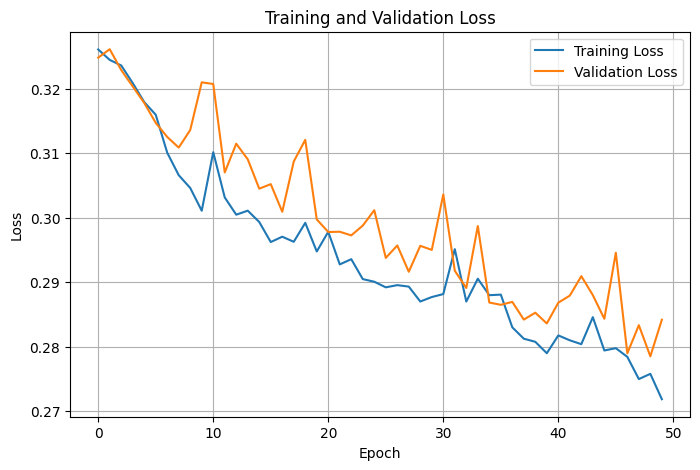

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

model.eval()

all_predictions = []
all_probabilities = []
all_labels = []

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        logits = model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        probabilities = torch.sigmoid(logits)

        predictions = (
            probabilities >= 0.5
        ).long()

        all_probabilities.extend(
            probabilities.cpu().numpy().flatten()
        )

        all_predictions.extend(
            predictions.cpu().numpy().flatten()
        )

        all_labels.extend(
            batch.y.cpu().numpy().flatten()
        )

In [ ]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions
)

recall = recall_score(
    all_labels,
    all_predictions
)

f1 = f1_score(
    all_labels,
    all_predictions
)

roc_auc = roc_auc_score(
    all_labels,
    all_probabilities
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.7288
Precision: 0.8416
Recall   : 0.7949
F1-score : 0.8176
ROC-AUC  : 0.7485


In [ ]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "Non-BBB-permeable",
            "BBB-permeable"
        ]
    )
)

                   precision    recall  f1-score   support

Non-BBB-permeable       0.44      0.51      0.47        72
    BBB-permeable       0.84      0.79      0.82       234

         accuracy                           0.73       306
        macro avg       0.64      0.65      0.64       306
     weighted avg       0.75      0.73      0.74       306



In [ ]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

[[ 37  35]
 [ 48 186]]


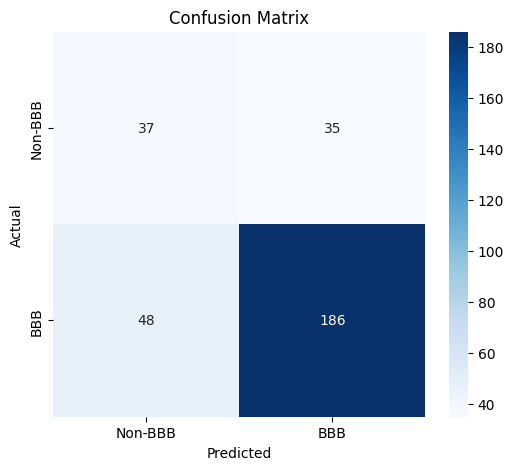

In [ ]:
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Non-BBB",
        "BBB"
    ],
    yticklabels=[
        "Non-BBB",
        "BBB"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
model_bce = GCNModel().to(device)

criterion_bce = nn.BCEWithLogitsLoss()

optimizer_bce = torch.optim.Adam(
    model_bce.parameters(),
    lr=0.001
)

In [ ]:
bce_train_losses = []
bce_val_losses = []

num_epochs = 50

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        model_bce,
        train_loader,
        optimizer_bce,
        criterion_bce,
        device
    )

    val_loss = evaluate_loss(
        model_bce,
        val_loader,
        criterion_bce,
        device
    )

    bce_train_losses.append(train_loss)
    bce_val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 01/50 | Train Loss: 0.5604 | Val Loss: 0.5457
Epoch 02/50 | Train Loss: 0.5457 | Val Loss: 0.5448
Epoch 03/50 | Train Loss: 0.5478 | Val Loss: 0.5414
Epoch 04/50 | Train Loss: 0.5416 | Val Loss: 0.5395
Epoch 05/50 | Train Loss: 0.5382 | Val Loss: 0.5359
Epoch 06/50 | Train Loss: 0.5327 | Val Loss: 0.5430
Epoch 07/50 | Train Loss: 0.5287 | Val Loss: 0.5343
Epoch 08/50 | Train Loss: 0.5255 | Val Loss: 0.5265
Epoch 09/50 | Train Loss: 0.5172 | Val Loss: 0.5226
Epoch 10/50 | Train Loss: 0.5185 | Val Loss: 0.5267
Epoch 11/50 | Train Loss: 0.5136 | Val Loss: 0.5530
Epoch 12/50 | Train Loss: 0.5076 | Val Loss: 0.5221
Epoch 13/50 | Train Loss: 0.5073 | Val Loss: 0.5212
Epoch 14/50 | Train Loss: 0.5045 | Val Loss: 0.5223
Epoch 15/50 | Train Loss: 0.5070 | Val Loss: 0.5225
Epoch 16/50 | Train Loss: 0.5030 | Val Loss: 0.5103
Epoch 17/50 | Train Loss: 0.5031 | Val Loss: 0.5106
Epoch 18/50 | Train Loss: 0.4980 | Val Loss: 0.5113
Epoch 19/50 | Train Loss: 0.5013 | Val Loss: 0.5069
Epoch 20/50 

In [ ]:
def evaluate_model(model, loader, device):

    model.eval()

    all_predictions = []
    all_probabilities = []
    all_labels = []

    with torch.no_grad():

        for batch in loader:

            batch = batch.to(device)

            logits = model(
                batch.x,
                batch.edge_index,
                batch.batch
            )

            probabilities = torch.sigmoid(logits)

            predictions = (
                probabilities >= 0.5
            ).long()

            all_probabilities.extend(
                probabilities.cpu().numpy().flatten()
            )

            all_predictions.extend(
                predictions.cpu().numpy().flatten()
            )

            all_labels.extend(
                batch.y.cpu().numpy().flatten()
            )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        all_labels,
        all_probabilities
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    }

In [ ]:
bce_results = evaluate_model(
    model_bce,
    test_loader,
    device
)

for metric, value in bce_results.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.7745
Precision: 0.7759
Recall: 0.9915
F1: 0.8705
ROC-AUC: 0.7629


In [ ]:
model_bce.eval()

val_probabilities = []
val_labels = []

with torch.no_grad():

    for batch in val_loader:

        batch = batch.to(device)

        logits = model_bce(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        probabilities = torch.sigmoid(logits)

        val_probabilities.extend(
            probabilities.cpu().numpy().flatten()
        )

        val_labels.extend(
            batch.y.cpu().numpy().flatten()
        )

val_probabilities = np.array(val_probabilities)
val_labels = np.array(val_labels)

print("Validation samples:", len(val_labels))

Validation samples: 306


In [ ]:
threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    predictions = (
        val_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        val_labels,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        val_labels,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        val_labels,
        predictions,
        zero_division=0
    )

    accuracy = accuracy_score(
        val_labels,
        predictions
    )

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.to_string(index=False))

 Threshold  Accuracy  Precision   Recall       F1
      0.10  0.764706   0.764706 1.000000 0.866667
      0.15  0.764706   0.764706 1.000000 0.866667
      0.20  0.764706   0.764706 1.000000 0.866667
      0.25  0.764706   0.764706 1.000000 0.866667
      0.30  0.764706   0.764706 1.000000 0.866667
      0.35  0.764706   0.764706 1.000000 0.866667
      0.40  0.764706   0.764706 1.000000 0.866667
      0.45  0.764706   0.764706 1.000000 0.866667
      0.50  0.767974   0.770764 0.991453 0.867290
      0.55  0.797386   0.800699 0.978632 0.880769
      0.60  0.816993   0.820144 0.974359 0.890625
      0.65  0.833333   0.850575 0.948718 0.896970
      0.70  0.790850   0.854167 0.876068 0.864979
      0.75  0.728758   0.857820 0.773504 0.813483
      0.80  0.679739   0.877778 0.675214 0.763285
      0.85  0.571895   0.905512 0.491453 0.637119
      0.90  0.421569   0.925373 0.264957 0.411960


In [ ]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("Best threshold based on validation F1:")

print(best_threshold_row)

Best threshold based on validation F1:
Threshold    0.650000
Accuracy     0.833333
Precision    0.850575
Recall       0.948718
F1           0.896970
Name: 11, dtype: float64


In [ ]:
# Lock the threshold selected using the validation set
best_threshold = 0.65

model_bce.eval()

test_probabilities = []
test_labels = []

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        logits = model_bce(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        probabilities = torch.sigmoid(logits)

        test_probabilities.extend(
            probabilities.cpu().numpy().flatten()
        )

        test_labels.extend(
            batch.y.cpu().numpy().flatten()
        )

test_probabilities = np.array(test_probabilities)
test_labels = np.array(test_labels)

# Apply the selected threshold
test_predictions = (
    test_probabilities >= best_threshold
).astype(int)

print("Test samples:", len(test_labels))

Test samples: 306


In [ ]:
final_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

final_precision = precision_score(
    test_labels,
    test_predictions,
    zero_division=0
)

final_recall = recall_score(
    test_labels,
    test_predictions,
    zero_division=0
)

final_f1 = f1_score(
    test_labels,
    test_predictions,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    test_labels,
    test_probabilities
)

print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_roc_auc:.4f}")

Accuracy : 0.8137
Precision: 0.8365
Recall   : 0.9402
F1-score : 0.8853
ROC-AUC  : 0.7628


In [ ]:
final_cm = confusion_matrix(
    test_labels,
    test_predictions
)

print(final_cm)

[[ 29  43]
 [ 14 220]]


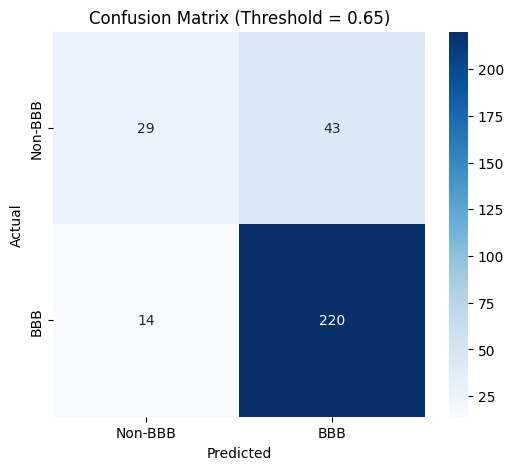

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Non-BBB",
        "BBB"
    ],
    yticklabels=[
        "Non-BBB",
        "BBB"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    f"Confusion Matrix (Threshold = {best_threshold})"
)

plt.show()

In [ ]:
print("Total graphs:", len(graphs))
print("Training graphs:", len(train_graphs))
print("Validation graphs:", len(val_graphs))
print("Test graphs:", len(test_graphs))

print(
    "Total split samples:",
    len(train_graphs) + len(val_graphs) + len(test_graphs)
)

Total graphs: 2039
Training graphs: 1427
Validation graphs: 306
Test graphs: 306
Total split samples: 2039
